In [139]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv


import nltk
from nltk.tokenize import sent_tokenize
# nltk.download('punkt')
# nltk.download('punkt_tab')

from tavily import TavilyClient

from typing import TypedDict,Literal

load_dotenv()
model = ChatOpenAI(model = 'gpt-4o-mini')
embeddings = OpenAIEmbeddings(model = 'text-embedding-3-small')

In [140]:
docs = PyPDFLoader(r"D:\LangGraph_Revision_Material\1745644084604-NumpyHandbook (1).pdf").load()

In [141]:
class state(TypedDict):
    query : str
    retrived_docs : list[Document]
    
    
    vardict : Literal['correct','incorrect','ambiguous']
    reason : str
    good_docs : list[Document]
    
    refined_query : str
    tavily_docs : list[Document]
    
    good_sentences : list[str]
    refine_context : str
    answer : str
    
    

In [142]:
chunker = RecursiveCharacterTextSplitter(chunk_size = 500,chunk_overlap = 100)
def chunk_doc(docs:Document)->list[Document]:
    chunked_doc = chunker.split_documents(docs)
    return chunked_doc
len(chunk_doc(docs))

57

In [143]:
def store():
    chunked_docs = chunk_doc(docs=docs)
    vector_store = Chroma(
        collection_name="numpy",
        embedding_function=embeddings,
        persist_directory="./chroma_langchain_db",  
    )
    # vector_store.add_documents(chunked_docs)
    return vector_store


In [144]:
def retrive(state : state):
    vector_store = store()
    retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})
    return {'retrived_docs':retriever.invoke(state['query'])}
    

In [145]:
UPPER_LIMIT = 0.7
LOWER_LIMIT = 0.3

In [146]:
EVAL_PROMPT = '''You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.'''

e_prompt = ChatPromptTemplate.from_messages([
    ("system",EVAL_PROMPT),
    ("human","chunk:\n{doc}\nQuery:\n{query}")
])
class eval(TypedDict):
    score: float
    
def evaluation(state:state):
    retrived_docs = state['retrived_docs']
    query = state['query']
    
    good_docs = []
    scores = []
    
    for doc in retrived_docs:
        chain = e_prompt | model.with_structured_output(eval)
        
        resp = chain.invoke({'doc':doc.page_content,'query':query})
        # print(resp)
        if(resp['score']>LOWER_LIMIT):
            good_docs.append(doc)
        scores.append(resp['score'])
        
    vardict = "ambiguous"
    reason = "All docs have score greater then 0.3 and less then 0.7"
    if any(s>=UPPER_LIMIT for s in scores):
        vardict = 'correct'
        reason = "Atleast one doc has score greater then 0.7"
    if all(s<LOWER_LIMIT for s in scores):
        vardict = 'incorrect'
        reason = 'None of the docs have score greater then 0.3'
    return {'good_docs':good_docs,'vardict':vardict,"reason":reason}

In [147]:
class q(TypedDict):
    query : str
    
def refine_query(state:state):
    query = state['query']
    
    query_prompt = ChatPromptTemplate([
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human",("Query : {query}"))
    ])
    
    chain = query_prompt | model.with_structured_output(q)
    resp = chain.invoke({'query':query})
    return {"refined_query": resp['query']}
    
    
    

In [ ]:
def tavily_search(state: state):
    client = TavilyClient()
    query = state['refined_query']
    
    
    
    response = client.search(
        query=query,
        search_depth="advanced",
        max_results=5
    )
    
    tavily_docs = []
    
    for resp in response["results"]:

        metadata = {
            "url": resp["url"],
            "title": resp["title"]
        }

        doc = Document(
            page_content=resp["content"],
            metadata=metadata
        )

        tavily_docs.append(doc)
        
    return {"tavily_docs":tavily_docs}

In [149]:


class refine_schema(TypedDict):
    keep : bool

REFINE_PROMPT= """
            You are a strict relevance filter.\n
            Return keep=true only if the sentence directly helps answer the question.\n
            Use ONLY the sentence. Output JSON only.
            """

filter_prompt = ChatPromptTemplate.from_messages(
    [
        ("system",REFINE_PROMPT),
        ("human", "Question: {question}\n\nSentence:\n{sentence}")
    ]
)

def refine(state:state):
    query = state['query']
    
    vardict = state['vardict']
    if vardict == 'correct':
        good_docs = state['good_docs']
    if vardict == 'incorrect':
        good_docs = state['tavily_docs']
    if vardict == 'ambiguous':
        good_docs = state['tavily_docs'] + state['good_docs']
    
    sentences = []
    for doc in good_docs:
        snt = sent_tokenize(doc.page_content)
        sentences.extend(snt)
    
    good_sent = []
    refine_chain = filter_prompt | model.with_structured_output(refine_schema)
    for sen in sentences:
        if refine_chain.invoke({'question':query,'sentence':sen})['keep']:
            good_sent.append(sen)
            
    refined_context = ".".join(good_sent).strip()
    return {
        'good_sentences':good_sent,
        'refine_context':refined_context
    }
    

In [150]:
def route(state:state) -> Literal['refine_query','refine']:
    vard = state['vardict']
    if vard == 'correct':
        return 'refine'
    if vard == 'incorrect':
        return 'refine_query'
    if vard == 'ambiguous':
        return 'refine_query'

In [151]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)

def generation(state:state):
    query = state['query']
    context = state['refine_context']
        
    
    parser = StrOutputParser()
    chain = prompt | model | parser
    
    return {"answer":chain.invoke({'question':query,"context":context})}
    
    

In [152]:
graph = StateGraph(state)

graph.add_node('retrive',retrive)
graph.add_node('evaluation',evaluation)
graph.add_node('refine',refine)
graph.add_node('tavily_search',tavily_search)
graph.add_node('refine_query',refine_query)
graph.add_node('generate',generation)

graph.add_edge(START,'retrive')
graph.add_edge('retrive','evaluation')
graph.add_conditional_edges('evaluation',route)
graph.add_edge('refine_query','tavily_search')
graph.add_edge('tavily_search','refine')
graph.add_edge('refine','generate')
graph.add_edge('generate',END)

workflow = graph.compile()

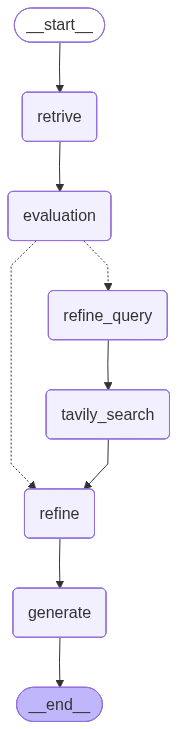

In [153]:
workflow

In [154]:
res = workflow.invoke({'query':"what is numpy index and what panda eats"})

In [155]:
res

{'query': 'what is numpy index and what panda eats',
 'retrived_docs': [Document(id='b2a8ad32-6321-495c-9594-e2607a81e883', metadata={'creator': 'PyPDF', 'source': 'D:\\LangGraph_Revision_Material\\1745644084604-NumpyHandbook (1).pdf', 'page_label': '7', 'producer': 'WeasyPrint 65.0', 'title': 'Numpy Handbook - Data Science Course', 'total_pages': 23, 'creationdate': '', 'page': 6}, page_content='Indexing (Same as Python Lists)\nSlicing (Extracting Parts of an Array)\nSlicing returns a view, not a copy! Changes affect the original\narray.**\nThis might seem counterintuitive since Python lists create copies when sliced. But\nin NumPy, slicing returns a view of the original array. Both the sliced array and the\noriginal array share the same data in memory, so changes in the slice affect the\noriginal array.\nWhy does this happen?'),
  Document(id='6b0bcb7e-1fb0-4119-9373-3846dbd5c582', metadata={'title': 'Numpy Handbook - Data Science Course', 'creationdate': '', 'page': 6, 'page_label':

In [156]:
print(res['answer'])

A NumPy index refers to the internal indices used to access elements in a NumPy array, which are 0-based indices like `0, 1, 2...`. Giant pandas primarily eat bamboo, with around 99% of their diet consisting of various bamboo species. They consume large amounts, typically between 9 to 14 kg (20 to 31 lb) of bamboo shoots per day, and can eat up to 50 pounds of bamboo daily.
